# 🐍 Python Level 3 - Advanced course
## Class 1 — Databases with SQLite

**Python instructor - Catarina Santos**

---

<div style="display:inline-flex; align-items:center; gap:28px; background:#FFFFFF; color:#1D1D1B; padding:10px 14px; border-radius:8px; margin-bottom:8px;">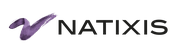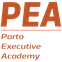</div>

---

---

### 📋 What we'll cover today

| # | Topic |
|---|-------|
| 1 | Why a database, and not a CSV? |
| 2 | Connecting, and creating a table |
| 3 | Adding rows |
| 4 | Reading rows — `SELECT` |
| 5 | Changing rows — `UPDATE` and `DELETE` |
| 6 | Summarising — `COUNT`, `SUM`, `AVG`, `GROUP BY` |
| 7 | pandas and SQL together |
| 8 | 🔗 Putting it all together |

### 🎯 Learning outcomes

By the end of this class you will be able to:

- Say when a database is the right answer and when a file will do
- Create a table, put rows in it, and get them back out
- Ask a database a question in SQL instead of loading everything
- Move data between pandas and a database in both directions

---

> 💡 **Welcome to Level 3.** Levels 1 and 2 were about working with data that arrives in a file.
> Level 3 is about building something that lasts: data that persists, code organised into
> objects, and a project split across files.

---
## 1. Why a database, and not a CSV?

For two levels you have loaded a CSV, worked on it, and written it back out. That works — until
it doesn't:

| | A CSV file                          | A database                         |
|---|-------------------------------------|------------------------------------|
| Reading part of it | Load all of it, then filter         | Ask for **only** the rows you want |
| Changing one row | Rewrite the whole file              | Change that one row                |
| Two people at once | One quietly overwrites the other    | Handled for you                    |
| Rules about the data | None; anything can go in any column | Each column declares a type        |
| Size | Fine to a few hundred thousand rows | Millions                           |

The rule of thumb: **a CSV is a document, a database is a system.** If the data is read once
and thrown away, a file is fine. If it is added to, corrected and queried over time — payments,
customers, transactions — it belongs in a database.

### The words

| Word | Means                              | You already know it as |
|------|------------------------------------|------------------------|
| **Table** | A grid of data with named columns  | a DataFrame, or a sheet |
| **Row** | One record                         | a row of a DataFrame |
| **Column** | One field, with a declared type    | a column of a DataFrame |
| **Query** | A question you ask, written in SQL | `df[df["status"] == "pending"]` |

**SQL** is the language you ask in. It is not Python — it is a separate language you send *from*
Python, as a string. It reads close to English: `SELECT amount FROM payments WHERE status =
'pending'`.

We use **SQLite**: a whole database kept in a single file, with nothing to install. It comes
with Python. It is also what your phone uses for its messages, so it is not a toy.

---
## 2. Connecting, and creating a table

Three objects, always in the same order. This is the shape of every database program you will
ever write:

```
   your Python program
        │
        ▼
   connect("payments.db")   open the file (creates it if new)
        │
        ▼
   cursor()                 the thing that runs SQL for you
        │
        ▼
   execute("SELECT ...")    send one SQL statement
        │
        ▼
   fetchall()               collect the rows it sends back
        │
        ▼
   commit()  /  close()     save the changes, then let go
```

### Creating a table

`CREATE TABLE` names the table and lists its columns with a **type** each:

| SQL type | Holds | Python equivalent |
|----------|-------|-------------------|
| `TEXT` | words | `str` |
| `INTEGER` | whole numbers | `int` |
| `REAL` | decimals | `float` |

> ⚠️ **A notebook gets re-run.** `CREATE TABLE` on a table that already exists is an error, so
> we write `CREATE TABLE IF NOT EXISTS`. And because the rows would otherwise pile up on every
> run, we clear it first with `DELETE FROM`. Without those two habits your totals double every
> time you press ▶.

### Where the file actually goes

`sqlite3.connect("payments.db")` creates a real file — but **on Colab's own computer, not
yours**. That space is wiped when your session ends, so the database is gone the next time you
open the notebook.

That is fine for today: everything we do runs in one sitting. But it is worth knowing, because
a database whose whole point is to *last* deserves somewhere lasting to live. One line changes
that:

| Written as | The file lives | Survives closing Colab? |
|------------|----------------|------------------------|
| `sqlite3.connect("payments.db")` | Colab's temporary space | ❌ no |
| `sqlite3.connect("/content/drive/MyDrive/payments.db")` | your Google Drive | ✅ yes |

We use the short version today so nothing depends on the Drive being connected. Use the long
one whenever you want to come back to the data tomorrow.

In [ ]:
import sqlite3

connection = sqlite3.connect("payments.db")   # opens the file, or creates it
cursor = connection.cursor()                  # the thing that runs SQL

cursor.execute("""
    CREATE TABLE IF NOT EXISTS payments (
        reference TEXT,
        supplier  TEXT,
        amount    REAL,
        currency  TEXT,
        status    TEXT
    )
""")

cursor.execute("DELETE FROM payments")        # start clean, so re-running is safe
connection.commit()                           # nothing is saved until you commit

print("Table ready")

---
## 3. Adding rows

`INSERT INTO` adds a row. The values do **not** go straight into the SQL string — you put a `?`
for each one and pass the values separately:

```
cursor.execute("INSERT INTO payments VALUES (?, ?, ?, ?, ?)", one_row)
```

> ⚠️ Always use `?`. Building the SQL by gluing text together (`"... VALUES ('" + name + "')"`)
> breaks the moment a value contains an apostrophe, and is the classic way databases get
> attacked. The `?` is not extra work — it is less.

`.executemany()` runs the same statement once per row in a list. One call, eight rows.

And **nothing is saved until `connection.commit()`**. Forgetting it is the most common mistake
in this class: your code runs, prints nothing wrong, and the file is unchanged.

In [ ]:
payments = [
    ("PAY-001", "Alpha Supplies",  1250.00, "EUR", "pending"),
    ("PAY-002", "Delta Services",   480.50, "EUR", "paid"),
    ("PAY-003", "Alpha Supplies",  2400.00, "USD", "pending"),
    ("PAY-004", "Kestrel Print",     95.20, "EUR", "paid"),
    ("PAY-005", "Delta Services",  3100.00, "USD", "failed"),
    ("PAY-006", "Northwind Ltd",    640.00, "GBP", "pending"),
    ("PAY-007", "Kestrel Print",    210.75, "EUR", "paid"),
    ("PAY-008", "Northwind Ltd",   1875.00, "GBP", "paid"),
]

cursor.executemany("INSERT INTO payments VALUES (?, ?, ?, ?, ?)", payments)
connection.commit()

print("Rows inserted:", cursor.rowcount)

---
## 4. Reading rows — `SELECT`

`SELECT` asks for data. The shape is always the same:

```
SELECT  which columns   FROM  which table   WHERE  which rows   ORDER BY  what order
```

| Piece | Does | Optional? |
|-------|------|-----------|
| `SELECT *` | every column — or name them: `SELECT reference, amount` | no |
| `FROM payments` | which table | no |
| `WHERE status = 'pending'` | keeps only matching rows | yes |
| `ORDER BY amount DESC` | sorts — `DESC` for biggest first, `ASC` is the default | yes |
| `LIMIT 3` | only the first few | yes |

Then you collect the answer:

- `.fetchall()` — **all** the rows, as a list of tuples
- `.fetchone()` — just the ***next*** row

> 💡 Text in SQL goes in **single** quotes: `WHERE status = 'pending'`. Your Python string uses
> double quotes around the whole thing, so the two never collide.

In [ ]:
# Everything
cursor.execute("SELECT * FROM payments")
for row in cursor.fetchall():
    print(row)

In [ ]:
# Only some columns, only some rows, in an order we choose
cursor.execute("""
    SELECT reference, supplier, amount
    FROM payments
    WHERE status = 'pending'
    ORDER BY amount DESC
""")

for reference, supplier, amount in cursor.fetchall():    # each row is a tuple
    print(f"{reference}  {supplier:<16}{amount:>9.2f}")

In [ ]:
# The single biggest payment - LIMIT plus fetchone()
cursor.execute("SELECT reference, amount FROM payments ORDER BY amount DESC LIMIT 1")
print("Biggest:", cursor.fetchone())

In [ ]:
# A ? works in a WHERE too, and should be used there as well.
# Note the comma: the values always come as a tuple, even when there is only one value.
cursor.execute("SELECT reference, amount FROM payments WHERE currency = ?", ("GBP",))
print("In GBP :", cursor.fetchall())

---
## 5. Changing rows — `UPDATE` and `DELETE`

| Statement | Does |
|-----------|------|
| `UPDATE payments SET status = 'paid' WHERE reference = 'PAY-001'` | changes matching rows |
| `DELETE FROM payments WHERE reference = 'PAY-005'` | removes matching rows |

Both take a `WHERE`, and both need a `commit()`.

> ⚠️ **`UPDATE` and `DELETE` without a `WHERE` hit every row in the table.** `DELETE FROM
> payments` empties it — which is exactly what we wanted in section 2, and exactly what you do
> not want here. Before running either, read your `WHERE` twice. A good habit: run it as a
> `SELECT` first to see which rows you are about to change.

In [ ]:
# Look before you change: which rows will this touch?
cursor.execute("SELECT reference, status FROM payments WHERE reference = ?", ("PAY-001",))
print("Before:", cursor.fetchall())

cursor.execute("UPDATE payments SET status = ? WHERE reference = ?", ("paid", "PAY-001"))
connection.commit()

cursor.execute("SELECT reference, status FROM payments WHERE reference = ?", ("PAY-001",))
print("After :", cursor.fetchall())

In [ ]:
# Remove the failed payment
cursor.execute("DELETE FROM payments WHERE status = ?", ("failed",))
connection.commit()
print("Rows deleted:", cursor.rowcount)

cursor.execute("SELECT COUNT(*) FROM payments")
print("Rows left   :", cursor.fetchone()[0])

---
## 6. Summarising — `COUNT`, `SUM`, `AVG`, `GROUP BY`

SQL can do the arithmetic for you, before the data ever reaches Python.

| Function | Gives |
|----------|-------|
| `COUNT(*)` | how many rows |
| `SUM(amount)` | the total |
| `AVG(amount)` | the average |
| `MIN(amount)` / `MAX(amount)` | smallest / largest |

`GROUP BY` does per-group what `.groupby()` does in pandas — and the two read almost the same:

| pandas | SQL |
|--------|-----|
| `df.groupby("currency")["amount"].sum()` | `SELECT currency, SUM(amount) FROM payments GROUP BY currency` |

`AS` renames a result column, which makes the output readable:
`SELECT SUM(amount) AS total FROM payments`.

> 💡 Let the database do the maths. `SELECT SUM(amount)` adds up ten million rows inside the database and sends back **one number**. Loading those ten million rows into pandas first means moving all of them into Python, just to add them up. Same answer, much more work and weight.

In [ ]:
# One number out of the whole table, but with currencies mixed
cursor.execute("SELECT COUNT(*), SUM(amount), AVG(amount) FROM payments")
count, total, average = cursor.fetchone()
print(f"{count} payments, {total:,.2f} total, {average:,.2f} average")

In [ ]:
# Per group (currency): now each total means something
# The same question as a pandas groupby
cursor.execute("""
    SELECT currency, COUNT(*) AS payments, SUM(amount) AS total
    FROM payments
    GROUP BY currency
    ORDER BY total DESC
""")

print(f"{'currency':<10}{'count':>6}{'total':>12}")
for currency, number, subtotal in cursor.fetchall():
    print(f"{currency:<10}{number:>6}{subtotal:>12.2f}")

---
## 7. pandas and SQL together

They are not rivals. The usual split: **SQL narrows the data down, pandas does the analysis.**

| Direction | Call |
|-----------|------|
| Database → DataFrame | `pd.read_sql_query("SELECT ...", connection)` |
| DataFrame → database | `df.to_sql("table_name", connection, if_exists="replace", index=False)` |

`read_sql_query` hands you a real DataFrame — every method from Level 1 works on it. And
`to_sql` writes a whole DataFrame into a table in one line, which is how you get two levels of
CSV work into a database.

> 💡 `if_exists="replace"` overwrites the table if it is already there — which is what makes
> the cell safe to re-run. The alternative, `"append"`, adds to it and will double your data.

In [ ]:
import pandas as pd

# Database -> DataFrame, and the query does the filtering
pending = pd.read_sql_query(
    "SELECT supplier, amount, currency FROM payments WHERE status = 'pending'",
    connection,
)
print(pending)
print()
print("Total pending, mixed:", pending["amount"].sum())

print()
print("Total pending, per currency:")
print(pending.groupby("currency")["amount"].sum())

In [ ]:
# DataFrame -> database: the expenses file you have used since Level 1

# from google.colab import drive
# drive.mount('/content/drive')

CSV_PATH = "expenses.csv"

expenses = pd.read_csv(CSV_PATH).drop_duplicates()
expenses["department"] = expenses["department"].str.lower()
expenses = expenses.drop(columns=["notes"]).dropna(subset=["actual"])

expenses.to_sql("expenses", connection, if_exists="replace", index=False)
print("Wrote", len(expenses), "rows into the database")
print()

# Now ask SQL the question instead of pandas
top = pd.read_sql_query("""
    SELECT department, SUM(actual) AS total
    FROM expenses
    GROUP BY department
    ORDER BY total DESC
    LIMIT 3
""", connection)
print(top)

# MANDATORY last step
connection.close()

---
## 8. 🔗 Putting it all together — a payments store

Everything from today, as the job it actually is.

### The situation

Payments to suppliers arrive through the day. They need somewhere to live that can be added to,
corrected and asked questions of, not a file that gets rewritten each time. You will build that
store, run a day's worth of activity through it, and produce the end-of-day summary.

### What the program must do

1. **Open** the database and create the table if it is not there
2. **Clear** it, so re-running the notebook is safe
3. **Insert** the day's payments in one call
4. **Query** the ones still pending, biggest first
5. **Correct** one payment that has now gone through, and remove one that was cancelled
6. **Summarise** by supplier and currency, count and total, with SQL doing the arithmetic
7. **Hand it to pandas** for the final table, then close the connection properly

### Where each concept appears

| Concept from today | Where it is used |
|--------------------|------------------|
| `connect`, `cursor`, `commit`, `close` | opening and closing the store |
| `CREATE TABLE IF NOT EXISTS` | step 1 |
| `DELETE FROM` | step 2, and again in step 5 |
| `INSERT INTO` with `executemany` and `?` | step 3 |
| `SELECT`, `WHERE`, `ORDER BY` | step 4 |
| `UPDATE ... SET ... WHERE` | step 5 |
| `COUNT`, `SUM`, `GROUP BY`, `AS` | step 6 |
| `pd.read_sql_query` | step 7 |
| Tuples, f-strings, `for` | from Level 1 |

> ⚠️ These five cells are **one program**, split so each step fits on screen.
> Run them in order, top to bottom. To start again, run from the first cell.

In [ ]:
# ── 1-3. Open the store, start from a known state, load the day's payments ──
connection = sqlite3.connect("payments.db")
cursor = connection.cursor()

cursor.execute("""CREATE TABLE IF NOT EXISTS payments (
                reference TEXT,
                supplier TEXT,
                amount REAL,
                currency TEXT,
                status TEXT)
             """)
cursor.execute("DELETE FROM payments")
cursor.executemany("INSERT INTO payments VALUES (?, ?, ?, ?, ?)", payments) # same payments list from section 3
connection.commit()

print("Store ready:", cursor.rowcount, "payments loaded")

In [ ]:
# ── 4. What is still pending? ──
cursor.execute("SELECT reference, supplier, amount FROM payments"
               " WHERE status = 'pending' ORDER BY amount DESC")
for reference, supplier, amount in cursor.fetchall():
    print(f"{reference}  {supplier:<16}{amount:>9.2f}")

In [ ]:
# ── 5. One payment went through, and one was cancelled ──
cursor.execute("UPDATE payments SET status = ? WHERE reference = ?", ("paid", "PAY-003"))
print("Updated:", cursor.rowcount)
cursor.execute("DELETE FROM payments WHERE reference = ?", ("PAY-005",))
print("Deleted:", cursor.rowcount)
connection.commit()

In [ ]:
# ── 6. The end-of-day summary, worked out by SQL ──
cursor.execute("""
    SELECT supplier, currency, COUNT(*) AS payments, SUM(amount) AS total
    FROM payments
    GROUP BY supplier, currency
    ORDER BY supplier, total DESC
""")
print(f"{'supplier':<16}{'cur':<5}{'count':>6}{'total':>12}")
for supplier, currency, number, total in cursor.fetchall():
    print(f"{supplier:<16}{currency:<5}{number:>6}{total:>12.2f}")

In [ ]:
# ── 7. Hand the result to pandas, then close properly ──
summary = pd.read_sql_query(
    "SELECT status, currency, COUNT(*) AS payments, SUM(amount) AS total"
    " FROM payments GROUP BY status, currency ORDER BY status, currency", connection)
print(summary)

connection.close()
print("\nStore closed.")